In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image

# ========== НАСТРОЙКИ ==========
CSV_PATH = "/kaggle/input/datasets/davilsena/ckdataset/ckextended.csv"
OUTPUT_DIR = "/kaggle/working/ck_processed/train"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Словарь: номер эмоции → промпт
# CK+: 0=neutral, 1=anger, 2=contempt, 3=disgust, 4=fear, 5=happiness, 6=sadness, 7=surprise
EMOTION_MAP = {
    0: "a person with a neutral expression",
    1: "a person looking very angry",
    2: "a person with a contempt expression",
    3: "a person looking disgusted",
    4: "a person with a scared expression",
    5: "a person smiling happily",
    6: "a person looking sad and thoughtful",
    7: "a person with a surprised expression",
}

# ========== ЗАГРУЗКА CSV ==========
df = pd.read_csv(CSV_PATH)
print(len(df))
df = df[df.emotion.isin([0,1,5,6])]
print(len(df))

920
780


Загружено строк: 780
Колонки: ['emotion', 'pixels', 'Usage']
Уникальные эмоции: [np.int64(0), np.int64(1), np.int64(5), np.int64(6)]


/tmp/ipykernel_57/973492507.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(img_array, mode="L").convert("RGB")  # grayscale → RGB


  Обработано 100/780
  Обработано 200/780
  Обработано 300/780
  Обработано 400/780
  Обработано 500/780
  Обработано 700/780
  Обработано 900/780

✅ Готово: 780 изображений в /kaggle/working/ck_processed/train
✅ Metadata: /kaggle/working/ck_processed/metadata.csv

Пример восстановленного изображения ((512, 512)):


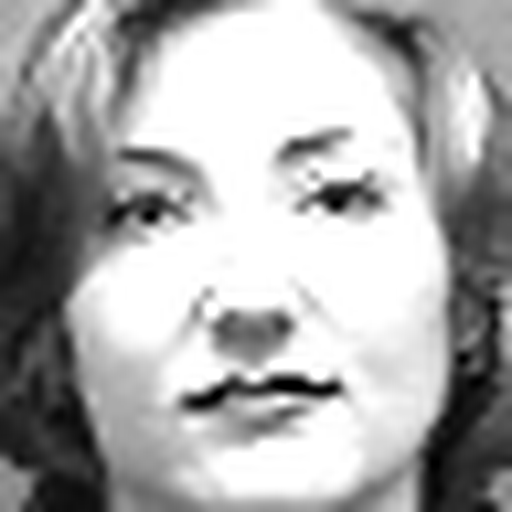

In [2]:

print(f"Загружено строк: {len(df)}")
print(f"Колонки: {df.columns.tolist()}")
print(f"Уникальные эмоции: {sorted(df['emotion'].unique())}")

# ========== ВОССТАНОВЛЕНИЕ ИЗОБРАЖЕНИЙ ==========
metadata_lines = []
image_size = 48  # CK+ обычно 48x48, но проверим по длине пикселей

for idx, row in df.iterrows():
    emotion = int(row["emotion"])
    pixels_str = row["pixels"]
    
    # Парсим строку пикселей в массив
    pixels = np.array([int(p) for p in pixels_str.split()], dtype=np.uint8)
    
    # Определяем размер изображения
    num_pixels = len(pixels)
    side = int(np.sqrt(num_pixels))
    
    if side * side != num_pixels:
        print(f"[WARN] Строка {idx}: {num_pixels} пикселей — не квадрат, пропускаем")
        continue
    
    # Восстанавливаем изображение
    img_array = pixels.reshape(side, side)
    img = Image.fromarray(img_array, mode="L").convert("RGB")  # grayscale → RGB
    img = img.resize((512, 512), Image.LANCZOS)
    
    # Сохраняем
    filename = f"ck_{idx:05d}_emotion_{emotion}.png"
    filepath = os.path.join(OUTPUT_DIR, filename)
    img.save(filepath)
    
    # Промпт
    prompt = EMOTION_MAP.get(emotion, "a person")
    metadata_lines.append(f"{filename},{prompt}")
    
    if (idx + 1) % 100 == 0:
        print(f"  Обработано {idx + 1}/{len(df)}")

# ========== СОХРАНЯЕМ METADATA ==========
metadata_path = "/kaggle/working/ck_processed/metadata.csv"
with open(metadata_path, "w", encoding="utf-8") as f:
    f.write("file_name,text\n")
    f.write("\n".join(metadata_lines))

print(f"\n✅ Готово: {len(metadata_lines)} изображений в {OUTPUT_DIR}")
print(f"✅ Metadata: {metadata_path}")

# Проверка — покажем одно изображение
from IPython.display import display
sample_img = Image.open(os.path.join(OUTPUT_DIR, os.listdir(OUTPUT_DIR)[0]))
print(f"\nПример восстановленного изображения ({sample_img.size}):")
display(sample_img)

In [ ]:
import torch
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from diffusers import StableDiffusionPipeline
from peft import LoraConfig, get_peft_model
import torch.nn.functional as F
from torch.optim import AdamW
# from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# ========== НАСТРОЙКИ ==========
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

TRAIN_DIR = "/kaggle/working/ck_processed/train"
METADATA_FILE = "/kaggle/working/ck_processed/metadata.csv"
LORA_OUTPUT = "/kaggle/working/lora_emotion"

# Куда сохранять чекпоинты
CHECKPOINT_DIR = "/kaggle/working/lora_emotion_continued"
FINAL_DIR = "/kaggle/working/lora_emotion_final"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FINAL_DIR, exist_ok=True)

NUM_EPOCHS = 30
BATCH_SIZE = 1
LEARNING_RATE = 1e-4
RANK = 4

# ========== ДАТАСЕТ ==========
class EmotionDataset(Dataset):
    def __init__(self, metadata_file, train_dir):
        self.train_dir = train_dir
        with open(metadata_file, "r") as f:
            lines = f.read().strip().split("\n")[1:]
        self.data = [line.split(",", 1) for line in lines if line.strip()]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_name, prompt = self.data[idx]
        img = Image.open(os.path.join(self.train_dir, file_name)).convert("RGB")
        img = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 127.5 - 1.0
        return {"pixel_values": img, "prompt": prompt}

dataset = EmotionDataset(METADATA_FILE, TRAIN_DIR)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Датасет: {len(dataset)} изображений")

# ========== ЗАГРУЗКА МОДЕЛИ ==========
print("Загрузка SD1.5...")
pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V4.0_noVAE",
    torch_dtype=DTYPE,
    use_safetensors=True,
)
pipe = pipe.to(DEVICE)

unet = pipe.unet
unet.train()

for param in unet.parameters():
    param.requires_grad = False

# ========== LoRA ==========
lora_config = LoraConfig(
    r=RANK,
    lora_alpha=RANK,
    target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    lora_dropout=0.0,
    bias="none",
)
unet = get_peft_model(unet, lora_config)
unet.print_trainable_parameters()

optimizer = AdamW(unet.parameters(), lr=LEARNING_RATE)
noise_scheduler = pipe.scheduler

# Кодируем текст
text_encoder = pipe.text_encoder
tokenizer = pipe.tokenizer

prompts = [item[1] for item in dataset.data] 
encoded_prompts = []
for prompt in prompts:#tqdm(prompts, desc="Кодирование текста"):
    tokens = tokenizer(
        prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt"
    ).input_ids.to(DEVICE)
    with torch.no_grad():
        emb = text_encoder(tokens).last_hidden_state
    encoded_prompts.append(emb)

# ========== ОБУЧЕНИЕ С ГРАФИКОМ ==========
print(f"\nОбучение {NUM_EPOCHS} эпох (loss = MSE шума)...")
epoch_losses = []
batch_losses = []

for epoch in range(NUM_EPOCHS):
    total_loss = 0
    # pbar = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")

    for batch_idx, batch in enumerate(dataloader):
        optimizer.zero_grad()

        img = batch["pixel_values"].to(DEVICE, dtype=DTYPE)
        prompt_emb = encoded_prompts[batch_idx]

        # Сначала кодируем изображение в латентное пространство
        with torch.no_grad():
            latents = pipe.vae.encode(img).latent_dist.sample() * pipe.vae.config.scaling_factor
        
        # Добавляем шум в латентном пространстве
        noise = torch.randn_like(latents)
        timestep = torch.randint(0, noise_scheduler.config.num_train_timesteps, (1,), device=DEVICE)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timestep)
        
        # UNet предсказывает шум в латентном пространстве
        noise_pred = unet(noisy_latents, timestep, encoder_hidden_states=prompt_emb).sample
        loss = F.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_losses.append(loss.item())
        # pbar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: avg_loss = {avg_loss:.6f}")

    # ========== ЧЕКПОИНТ КАЖДУЮ ЭПОХУ ==========
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"epoch_{(epoch+1):02d}")
    unet.save_pretrained(checkpoint_path)
    print(f"  💾 Чекпоинт сохранён: {checkpoint_path}")

# ========== СОХРАНЕНИЕ ==========
unet.save_pretrained(LORA_OUTPUT)
print(f"\n✅ LoRA сохранена: {LORA_OUTPUT}")

# ========== ГРАФИК ЛОССА ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Средний loss по эпохам
axes[0].plot(range(1, NUM_EPOCHS+1), epoch_losses, 'b-o', markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss (noise prediction)")
axes[0].set_title("Средний loss по эпохам")
axes[0].grid(True, alpha=0.3)

# График 2: Сглаженный loss по батчам
from scipy.ndimage import uniform_filter1d
smoothed = uniform_filter1d(batch_losses, size=10)
axes[1].plot(batch_losses, alpha=0.2, color='blue', label='Per batch')
axes[1].plot(smoothed, color='red', label='Smoothed (window=10)')
axes[1].set_xlabel("Batch")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title("Loss по батчам (сглаженный)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_plot.png", dpi=150)
plt.show()

print(f"✅ График сохранён: /kaggle/working/loss_plot.png")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Датасет: 780 изображений
Загрузка SD1.5...


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--Realistic_Vision_V4.0_noVAE/snapshots/1685907c0283c7278ba26c5fe561506f564b48d3/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 797,184 || all params: 860,318,148 || trainable%: 0.0927

Обучение 30 эпох (loss = MSE шума)...
Epoch 1: avg_loss = 0.137202
  💾 Чекпоинт сохранён: /kaggle/working/lora_emotion_continued/epoch_01
Epoch 2: avg_loss = 0.087787
  💾 Чекпоинт сохранён: /kaggle/working/lora_emotion_continued/epoch_02
Epoch 3: avg_loss = 0.082702
  💾 Чекпоинт сохранён: /kaggle/working/lora_emotion_continued/epoch_03
Epoch 4: avg_loss = 0.081682
  💾 Чекпоинт сохранён: /kaggle/working/lora_emotion_continued/epoch_04
Epoch 5: avg_loss = 0.076486
  💾 Чекпоинт сохранён: /kaggle/working/lora_emotion_continued/epoch_05
Epoch 6: avg_loss = 0.079287
  💾 Чекпоинт сохранён: /kaggle/working/lora_emotion_continued/epoch_06
Epoch 7: avg_loss = 0.073659
  💾 Чекпоинт сохранён: /kaggle/working/lora_emotion_continued/epoch_07
Epoch 8: avg_loss = 0.072721
  💾 Чекпоинт сохранён: /kaggle/working/lora_emotion_continued/epoch_08
Epoch 9: avg_loss = 0.071281
  💾 Чекпоинт сохранён: /kaggle/working/lora_emotion_conti

In [5]:
!ls /kaggle/input/datasets/kolyagudkov


5efit16


Датасет: 780 изображений
Загрузка SD1.5...


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--Realistic_Vision_V4.0_noVAE/snapshots/1685907c0283c7278ba26c5fe561506f564b48d3/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Загрузка чекпоинта: /kaggle/input/datasets/kolyagudkov/5efit16
trainable params: 797,184 || all params: 860,318,148 || trainable%: 0.0927
Кодирование текста...
  Готово: 780 эмбеддингов

Продолжение обучения: 12 эпох (с 17 по 28)
Learning rate: 5e-05
  Epoch 17, batch 0/780: loss = 0.003779
Epoch 17: avg_loss = 0.070278
  💾 Чекпоинт: /kaggle/working/lora_emotion_continued/epoch_17
  Epoch 18, batch 0/780: loss = 0.045303
Epoch 18: avg_loss = 0.071380
  💾 Чекпоинт: /kaggle/working/lora_emotion_continued/epoch_18
  Epoch 19, batch 0/780: loss = 0.009039
Epoch 19: avg_loss = 0.069195
  💾 Чекпоинт: /kaggle/working/lora_emotion_continued/epoch_19
  Epoch 20, batch 0/780: loss = 0.068273
Epoch 20: avg_loss = 0.065351
  💾 Чекпоинт: /kaggle/working/lora_emotion_continued/epoch_20
  Epoch 21, batch 0/780: loss = 0.365223
Epoch 21: avg_loss = 0.072280
  💾 Чекпоинт: /kaggle/working/lora_emotion_continued/epoch_21
  Epoch 22, batch 0/780: loss = 0.002389
Epoch 22: avg_loss = 0.069221
  💾 Чекпоинт:

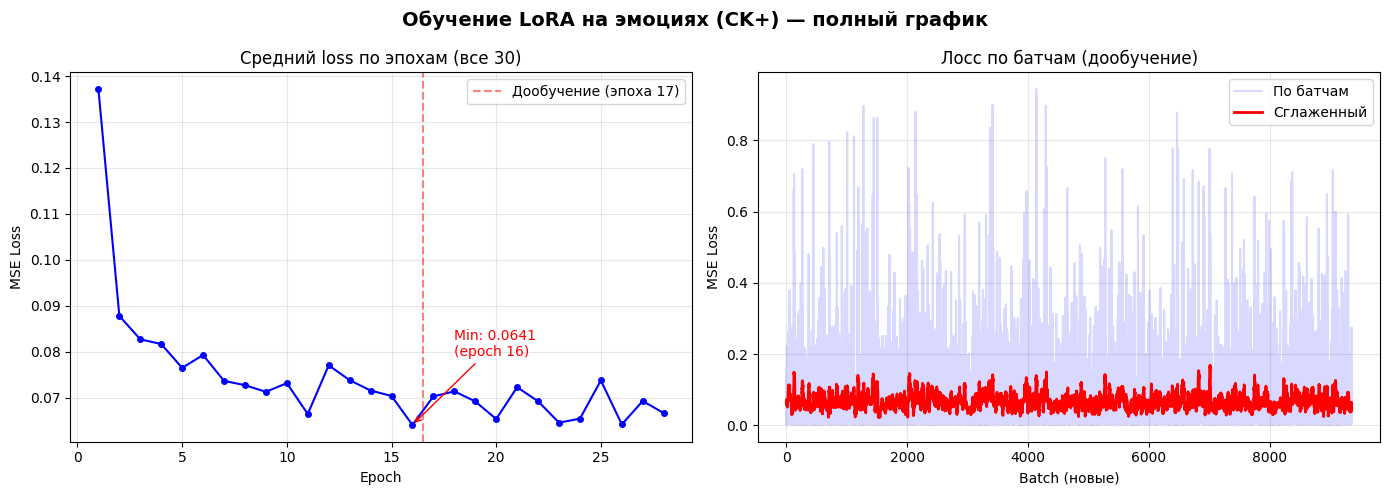

✅ График: /kaggle/working/lora_emotion_final/loss_plot_full.png
✅ Чекпоинты: /kaggle/working/lora_emotion_continued
✅ Итоговый список лоссов (28 эпох):
[0.137202, 0.087787, 0.082702, 0.081682, 0.076486, 0.079287, 0.073659, 0.072721, 0.071281, 0.073169, 0.066455, 0.077042, 0.07382, 0.071559, 0.070373, 0.064073, 0.07027788667682892, 0.07138041391855297, 0.06919515308810589, 0.06535129581864636, 0.07227984652481376, 0.06922077910500006, 0.06457330195131736, 0.06542480298114989, 0.07375754414660593, 0.06418652859910463, 0.06927834127981884, 0.0666604613350967]


In [7]:
import torch
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from diffusers import StableDiffusionPipeline
from peft import PeftModel
import torch.nn.functional as F
from torch.optim import AdamW
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

# ========== НАСТРОЙКИ ==========
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

TRAIN_DIR = "/kaggle/working/ck_processed/train"
METADATA_FILE = "/kaggle/working/ck_processed/metadata.csv"

# Чекпоинт 18-й эпохи
CHECKPOINT_16 = "/kaggle/input/datasets/kolyagudkov/5efit16"

# Куда сохранять
CHECKPOINT_DIR = "/kaggle/working/lora_emotion_continued"
FINAL_DIR = "/kaggle/working/lora_emotion_final"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(FINAL_DIR, exist_ok=True)

# Твой список лоссов за первые 18 эпох
l = [0.137202, 0.087787, 0.082702, 0.081682, 0.076486, 0.079287, 0.073659, 0.072721, 0.071281, 0.073169, 0.066455, 0.077042, 0.073820, 0.071559, 0.070373, 0.064073]
START_EPOCH = 16  # уже завершённых эпох
ADDITIONAL_EPOCHS = 12  # добьём до 30
BATCH_SIZE = 1
LEARNING_RATE = 5e-5  # уменьшаем для дообучения
RANK = 4

# ========== ДАТАСЕТ ==========
class EmotionDataset(Dataset):
    def __init__(self, metadata_file, train_dir):
        self.train_dir = train_dir
        with open(metadata_file, "r") as f:
            lines = f.read().strip().split("\n")[1:]
        self.data = [line.split(",", 1) for line in lines if line.strip()]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        file_name, prompt = self.data[idx]
        img = Image.open(os.path.join(self.train_dir, file_name)).convert("RGB")
        img = torch.tensor(np.array(img)).permute(2, 0, 1).float() / 127.5 - 1.0
        return {"pixel_values": img, "prompt": prompt}

dataset = EmotionDataset(METADATA_FILE, TRAIN_DIR)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"Датасет: {len(dataset)} изображений")

# ========== ЗАГРУЗКА МОДЕЛИ ==========
print("Загрузка SD1.5...")
pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V4.0_noVAE",
    torch_dtype=DTYPE,
    use_safetensors=True,
)
pipe = pipe.to(DEVICE)

# Загружаем чекпоинт 18-й эпохи
print(f"Загрузка чекпоинта: {CHECKPOINT_16}")
pipe.unet = PeftModel.from_pretrained(pipe.unet, CHECKPOINT_16)
pipe.unet.set_adapter("default")

unet = pipe.unet
unet.train()
unet.print_trainable_parameters()

optimizer = AdamW(unet.parameters(), lr=LEARNING_RATE)
noise_scheduler = pipe.scheduler

# Кодируем текст
text_encoder = pipe.text_encoder
tokenizer = pipe.tokenizer

prompts = [item[1] for item in dataset.data]
encoded_prompts = []
print("Кодирование текста...")
for prompt in prompts:
    tokens = tokenizer(
        prompt, padding="max_length", max_length=77, truncation=True, return_tensors="pt"
    ).input_ids.to(DEVICE)
    with torch.no_grad():
        emb = text_encoder(tokens).last_hidden_state
    encoded_prompts.append(emb)
print(f"  Готово: {len(encoded_prompts)} эмбеддингов")

# ========== ПРОДОЛЖЕНИЕ ОБУЧЕНИЯ ==========
print(f"\nПродолжение обучения: {ADDITIONAL_EPOCHS} эпох (с {START_EPOCH+1} по {START_EPOCH+ADDITIONAL_EPOCHS})")
print(f"Learning rate: {LEARNING_RATE}")

epoch_losses = l.copy()  # начинаем с твоего списка
batch_losses = []  # новые батчевые лоссы

for epoch in range(ADDITIONAL_EPOCHS):
    total_loss = 0
    current_epoch = START_EPOCH + epoch + 1

    for batch_idx, batch in enumerate(dataloader):
        optimizer.zero_grad()

        img = batch["pixel_values"].to(DEVICE, dtype=DTYPE)
        prompt_emb = encoded_prompts[batch_idx]

        # VAE encoding
        with torch.no_grad():
            latents = pipe.vae.encode(img).latent_dist.sample() * pipe.vae.config.scaling_factor

        # Шум в латентном пространстве
        noise = torch.randn_like(latents)
        timestep = torch.randint(0, noise_scheduler.config.num_train_timesteps, (1,), device=DEVICE)
        noisy_latents = noise_scheduler.add_noise(latents, noise, timestep)

        # UNet
        noise_pred = unet(noisy_latents, timestep, encoder_hidden_states=prompt_emb).sample
        loss = F.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        batch_losses.append(loss.item())

        if batch_idx % 5000 == 0:
            print(f"  Epoch {current_epoch}, batch {batch_idx}/{len(dataloader)}: loss = {loss.item():.6f}")

    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {current_epoch}: avg_loss = {avg_loss:.6f}")

    # Чекпоинт каждую эпоху
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"epoch_{current_epoch:02d}")
    unet.save_pretrained(checkpoint_path)
    print(f"  💾 Чекпоинт: {checkpoint_path}")

# ========== ФИНАЛЬНОЕ СОХРАНЕНИЕ ==========
unet.save_pretrained(FINAL_DIR)
print(f"\n✅ Финальная модель: {FINAL_DIR}")

# ========== ГРАФИК ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Средний loss по всем эпохам
all_epochs = range(1, len(epoch_losses) + 1)
axes[0].plot(all_epochs, epoch_losses, 'b-o', markersize=4)
axes[0].axvline(x=START_EPOCH + 0.5, color='red', linestyle='--', alpha=0.5, label=f'Дообучение (эпоха {START_EPOCH+1})')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Средний loss по эпохам (все 30)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Аннотация минимума
min_idx = np.argmin(epoch_losses)
axes[0].annotate(f"Min: {epoch_losses[min_idx]:.4f}\n(epoch {min_idx+1})",
                 xy=(min_idx+1, epoch_losses[min_idx]),
                 xytext=(min_idx+3, epoch_losses[min_idx] + 0.015),
                 arrowprops=dict(arrowstyle="->", color="red"),
                 fontsize=10, color="red")

# График 2: Сглаженный loss по батчам (только новые)
if len(batch_losses) > 20:
    smoothed = uniform_filter1d(batch_losses, size=min(20, len(batch_losses)//10))
    axes[1].plot(batch_losses, alpha=0.15, color='blue', label='По батчам')
    axes[1].plot(smoothed, color='red', linewidth=2, label='Сглаженный')
    axes[1].set_xlabel("Batch (новые)")
    axes[1].set_ylabel("MSE Loss")
    axes[1].set_title("Лосс по батчам (дообучение)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.suptitle("Обучение LoRA на эмоциях (CK+) — полный график", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, "loss_plot_full.png"), dpi=150)
plt.show()

print(f"✅ График: {os.path.join(FINAL_DIR, 'loss_plot_full.png')}")
print(f"✅ Чекпоинты: {CHECKPOINT_DIR}")
print(f"✅ Итоговый список лоссов ({len(epoch_losses)} эпох):")
print(epoch_losses)

In [8]:
# Просто печатаем что-то каждые 30 секунд
import time

while True:
    print(".", end="", flush=True)
    time.sleep(30)

.........................................................................................................................................................................................................................................................................................................

KeyboardInterrupt: 